In [27]:
import h5py
import requests
import matplotlib.pyplot as plt
import numpy as np
import time

In [3]:
key = "api_key.txt"

with open(key) as file :
    api_key = file.read()


In [4]:
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":f"{api_key}"}

def get(path, params=None):
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically
    
    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename # return the filename string
    
    return r

In [5]:
r = get(baseUrl)

print(r.keys())
print(len(r['simulations']))

print(r['simulations'][0])

dict_keys(['simulations'])
66
{'name': 'Illustris-1', 'num_snapshots': 134, 'url': 'http://www.tng-project.org/api/Illustris-1/'}


In [6]:
names = [sim['name'] for sim in r['simulations']]

print(names)


['Illustris-1', 'Illustris-1-Dark', 'Illustris-2', 'Illustris-2-Dark', 'Illustris-3', 'Illustris-3-Dark', 'TNG100-1', 'TNG100-1-Dark', 'TNG100-2', 'TNG100-2-Dark', 'TNG100-3', 'TNG100-3-Dark', 'TNG300-3', 'TNG300-2-Dark', 'TNG300-2', 'TNG300-1-Dark', 'TNG300-1', 'TNG300-3-Dark', 'TNG50-1', 'TNG50-1-Dark', 'TNG50-2', 'TNG50-2-Dark', 'TNG50-3', 'TNG50-3-Dark', 'TNG50-4', 'TNG50-4-Dark', 'TNG-Cluster', 'Illustris-1-Subbox0', 'Illustris-1-Subbox1', 'Illustris-1-Subbox2', 'Illustris-1-Subbox3', 'Illustris-2-Subbox0', 'Illustris-2-Subbox1', 'Illustris-2-Subbox2', 'Illustris-2-Subbox3', 'Illustris-3-Subbox0', 'Illustris-3-Subbox1', 'Illustris-3-Subbox2', 'Illustris-3-Subbox3', 'TNG100-1-Subbox0', 'TNG100-1-Subbox1', 'TNG100-2-Subbox0', 'TNG100-2-Subbox1', 'TNG100-3-Subbox0', 'TNG100-3-Subbox1', 'TNG300-3-Subbox1', 'TNG300-3-Subbox2', 'TNG300-3-Subbox0', 'TNG300-2-Subbox1', 'TNG300-2-Subbox2', 'TNG300-2-Subbox0', 'TNG300-1-Subbox1', 'TNG300-1-Subbox2', 'TNG300-1-Subbox0', 'TNG50-1-Subbox0', 'T

In [7]:
i = names.index('Illustris-3')
print(i)

4


In [8]:
sim = get( r['simulations'][i]['url'] )
print(sim.keys())
print('num_dm:', sim['num_dm'])

dict_keys(['name', 'description', 'name_alt', 'boxsize', 'z_start', 'z_final', 'cosmology', 'omega_0', 'omega_L', 'omega_B', 'hubble', 'physics_model', 'has_cooling', 'has_starformation', 'has_winds', 'has_blackholes', 'mass_gas', 'mass_dm', 'softening_dm_comoving', 'softening_stars_comoving', 'softening_blackholes_comoving', 'softening_gas_comoving', 'softening_dm_max_phys', 'softening_stars_max_phys', 'softening_blackholes_max_phys', 'softening_gas_max_phys', 'softening_gas_factor', 'softening_gas_comoving_min', 'num_dm', 'num_tr_mc', 'num_tr_vel', 'longids', 'is_uniform', 'is_zoom', 'is_subbox', 'num_files_snapshot', 'num_files_groupcat', 'num_files_rockstar', 'num_files_lhalotree', 'num_files_sublink', 'num_files_ctrees', 'filesize_lhalotree', 'filesize_sublink', 'filesize_ctrees', 'filesize_ics', 'filesize_simulation', 'has_fof', 'has_subfind', 'has_rockstar', 'has_lhalotree', 'has_sublink', 'has_ctrees', 'permission_required', 'num_snapshots', 'url', 'parent_simulation', 'child_s

In [9]:
snaps = get( sim['snapshots'] )
print(len(snaps))     # 136 total snapshots
print(snaps)    # last snapshot = z=0

136
[{'number': 0, 'redshift': 46.7730473053205, 'num_groups_subfind': 0, 'url': 'http://www.tng-project.org/api/Illustris-3/snapshots/0/'}, {'number': 1, 'redshift': 44.5622037875765, 'num_groups_subfind': 0, 'url': 'http://www.tng-project.org/api/Illustris-3/snapshots/1/'}, {'number': 2, 'redshift': 42.4536737988128, 'num_groups_subfind': 0, 'url': 'http://www.tng-project.org/api/Illustris-3/snapshots/2/'}, {'number': 3, 'redshift': 40.6395569311259, 'num_groups_subfind': 0, 'url': 'http://www.tng-project.org/api/Illustris-3/snapshots/3/'}, {'number': 4, 'redshift': 38.7125593934859, 'num_groups_subfind': 0, 'url': 'http://www.tng-project.org/api/Illustris-3/snapshots/4/'}, {'number': 5, 'redshift': 36.874739546094, 'num_groups_subfind': 0, 'url': 'http://www.tng-project.org/api/Illustris-3/snapshots/5/'}, {'number': 6, 'redshift': 35.1219704192563, 'num_groups_subfind': 0, 'url': 'http://www.tng-project.org/api/Illustris-3/snapshots/6/'}, {'number': 7, 'redshift': 33.6139396797829, 

In [10]:
snap = get( snaps[-1]['url'] )
print(snap)

{'simulation': 'http://www.tng-project.org/api/Illustris-3/', 'number': 135, 'redshift': 2.2204460492503099e-16, 'num_gas': 87571556, 'num_dm': 94196375, 'num_trmc': 94196375, 'num_stars': 4388167, 'num_bhs': 33582, 'num_groups_fof': 131727, 'num_groups_subfind': 121209, 'num_groups_rockstar': 0, 'filesize_snapshot': 23437820660.0, 'filesize_groupcat': 114056740.0, 'filesize_rockstar': 0.0, 'url': 'http://www.tng-project.org/api/Illustris-3/snapshots/135/', 'subhalos': 'http://www.tng-project.org/api/Illustris-3/snapshots/135/subhalos/', 'vis': {'groupcat_sfms': 'http://www.tng-project.org/api/Illustris-3/snapshots/135/subhalos/plot.png?xQuant=mstar2_log&yQuant=ssfr&xlim=9.0%2C11.0', 'groupcat_sizemass': 'http://www.tng-project.org/api/Illustris-3/snapshots/135/subhalos/plot.png?xQuant=mstar2_log&yQuant=size_stars', 'groupcat_mz_gas': 'http://www.tng-project.org/api/Illustris-3/snapshots/135/subhalos/plot.png?xQuant=mstar2_log&yQuant=Z_gas', 'groupcat_mz_stars': 'http://www.tng-project

In [11]:
subs = get( snap['subhalos'] )
print(subs.keys())
print(subs['count'])

dict_keys(['count', 'next', 'previous', 'results'])
121209


In [12]:
subs = get( snap['subhalos'], {'limit':220} )
print(len(subs['results']))

220


In [13]:
subs = get( snap['subhalos'], {'limit':20, 'order_by':'-mass_stars'} )
print(len(subs['results']))
print([ subs['results'][i]['id'] for i in range(5) ])

20
[0, 1030, 2074, 2302, 2843]


In [14]:
sub = get( subs['results'][1]['url'] )
url = sub['related']['parent_halo'] + "info.json"
parent_fof = get(url)

In [15]:
mpb1 = get( sub['trees']['sublink_mpb'] ) # file saved, mpb1 contains the filename

In [16]:
f = h5py.File(mpb1,'r')
#print (f.keys())
print (len(f['SnapNum']))
f.close()

104


In [17]:
mpb2 = get( sub['trees']['lhalotree_mpb'] ) # file saved, mpb2 contains the filename

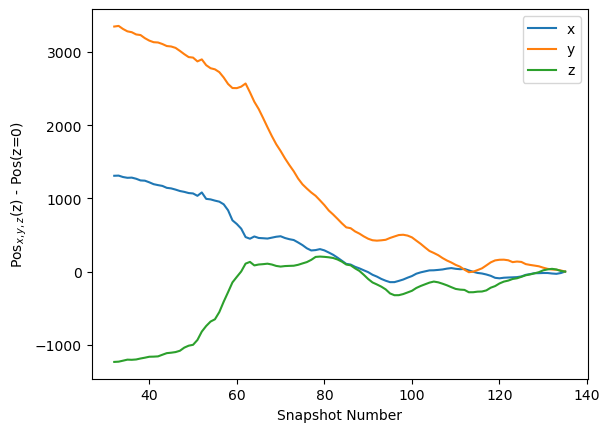

In [18]:
with h5py.File(mpb2,'r') as f:
    pos = f['SubhaloPos'][:]
    snapnum = f['SnapNum'][:]
    subid = f['SubhaloNumber'][:]

for i in range(3):
    plt.plot(snapnum,pos[:,i] - pos[0,i], label=['x','y','z'][i])
plt.legend()
plt.xlabel('Snapshot Number')
plt.ylabel('Pos$_{x,y,z}$(z) - Pos(z=0)');

In [19]:
url = sim['snapshots'] + "z=1/"
snap = get(url)
snap['number'], snap['redshift']

(85, 0.9972942257819399)

In [20]:
i = np.where(snapnum == 85)
subid[i]

array([185], dtype=int32)

In [21]:
sub_prog_url = "http://www.tng-project.org/api/Illustris-3/snapshots/85/subhalos/185/"
sub_prog = get(sub_prog_url)
sub_prog['pos_x'], sub_prog['pos_y']

cutout_request = {'gas':'Coordinates,Masses'}
cutout = get(sub_prog_url+"cutout.hdf5", cutout_request)

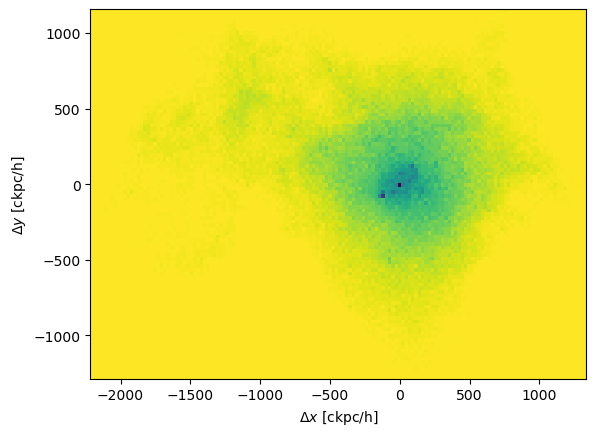

In [22]:
with h5py.File(cutout,'r') as f:
    x = f['PartType0']['Coordinates'][:,0] - sub_prog['pos_x']
    y = f['PartType0']['Coordinates'][:,1] - sub_prog['pos_y']
    dens = np.log10(f['PartType0']['Masses'][:])

plt.hist2d(x,y,weights=dens,bins=[150,100])
plt.xlabel('$\Delta x$ [ckpc/h]')
plt.ylabel('$\Delta y$ [ckpc/h]');

In [ ]:
subhalo_positions_np = {"x_pos": np.zeros(int(1e7)), "y_pos": np.zeros(int(1e7)), "z_pos": np.zeros(int(1e7))}

tstart2 = time.time()
for i in range(int(1e7)):
    subhalo_positions_np["x_pos"][i] = i
    subhalo_positions_np["y_pos"][i] = i
    subhalo_positions_np["z_pos"][i] = i
print("approach 2: ", -tstart2+time.time())

#do the subhalos in a different file to store that data

for snap in snaps[::-1]:
    snapResponse = get(snap['url'])
    subhalos = get(snapResponse['subhalos'])
    
    for i in range(subhalos['count']):
        subhalo = get(baseUrl + f'Illustris-3/snapshots/135/subhalos/{i}')
        print(subhalo)
    
        subhalo_positions_np["x_pos"][i] = subhalo['cm_x']
        subhalo_positions_np["y_pos"][i] = subhalo['cm_y']
        subhalo_positions_np["z_pos"][i] = subhalo['cm_z']
    break
    # if subhalos['count'] > 0:
    #     break

approach 1:  2.0221354961395264
approach 2:  1.6483981609344482
approach 3:  10.962392330169678


In [24]:
n_random = 5000 # 5*count
np.random.seed(42)

n_data = 1000
#need to replace with real data? cm_x, y, z?
data_points = np.random.rand(n_data,2)
random_points = np.random.rand(n_random,2)

cm_x = [-78, -54, 2, 112]

random_points = min(cm_x) + random_points * (max(cm_x) - min(cm_x))

bins = np.linspace(0.1, 1, 10) 

def count_pairs(points1, points2, bins):
    pair_counts = np.zeros(len(bins) - 1)
    
    for i in range(len(points1)):
        distances_sq = np.sum((points1[i] - points2) ** 2, axis=1)
        counts, _ = np.histogram(np.sqrt(distances_sq), bins = bins)
        pair_counts += counts

    return pair_counts
        
dd = count_pairs(data_points, data_points, bins)
dr = count_pairs(data_points, random_points, bins)
rr = count_pairs(random_points, random_points, bins)


#get the num of points in each catalog
nD = len(data_points)
nR = len(random_points)

dd = dd / (nD * (nD - 1) / 2)
dr = dr / (nD * nR)
rr = rr / (nR * (nR - 1) / 2)

In [ ]:
# COMPUTE THE 2PCF USING LANDY-SZALAY ESTIMATOR
#xi_unnormalized = (d - r)**2 = (d*d - d*r - r*d + r*r) = (dd - 2dr + rr)

xi = np.zeros_like(dd, dtype=float)
valid_bins = rr != 0
xi[valid_bins] = (dd[valid_bins] - 2 * dr[valid_bins] + rr[valid_bins]) / rr[valid_bins]
xi[~valid_bins] = np.nan # assign NaN where rr = 0

In [ ]:
plt.plot(subhalo_positions_np['x_pos'][:1000], subhalo_positions_np['y_pos'][:1000], "o")